# Introduction




# Prepare for analysis

## Load packages

In [112]:
import pandas as pd
import numpy as np
import sys
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

## Read the data

In [113]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")

# Preliminary data inspection

## Quick glimpse of the data

In [114]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [115]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [116]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [117]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [118]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


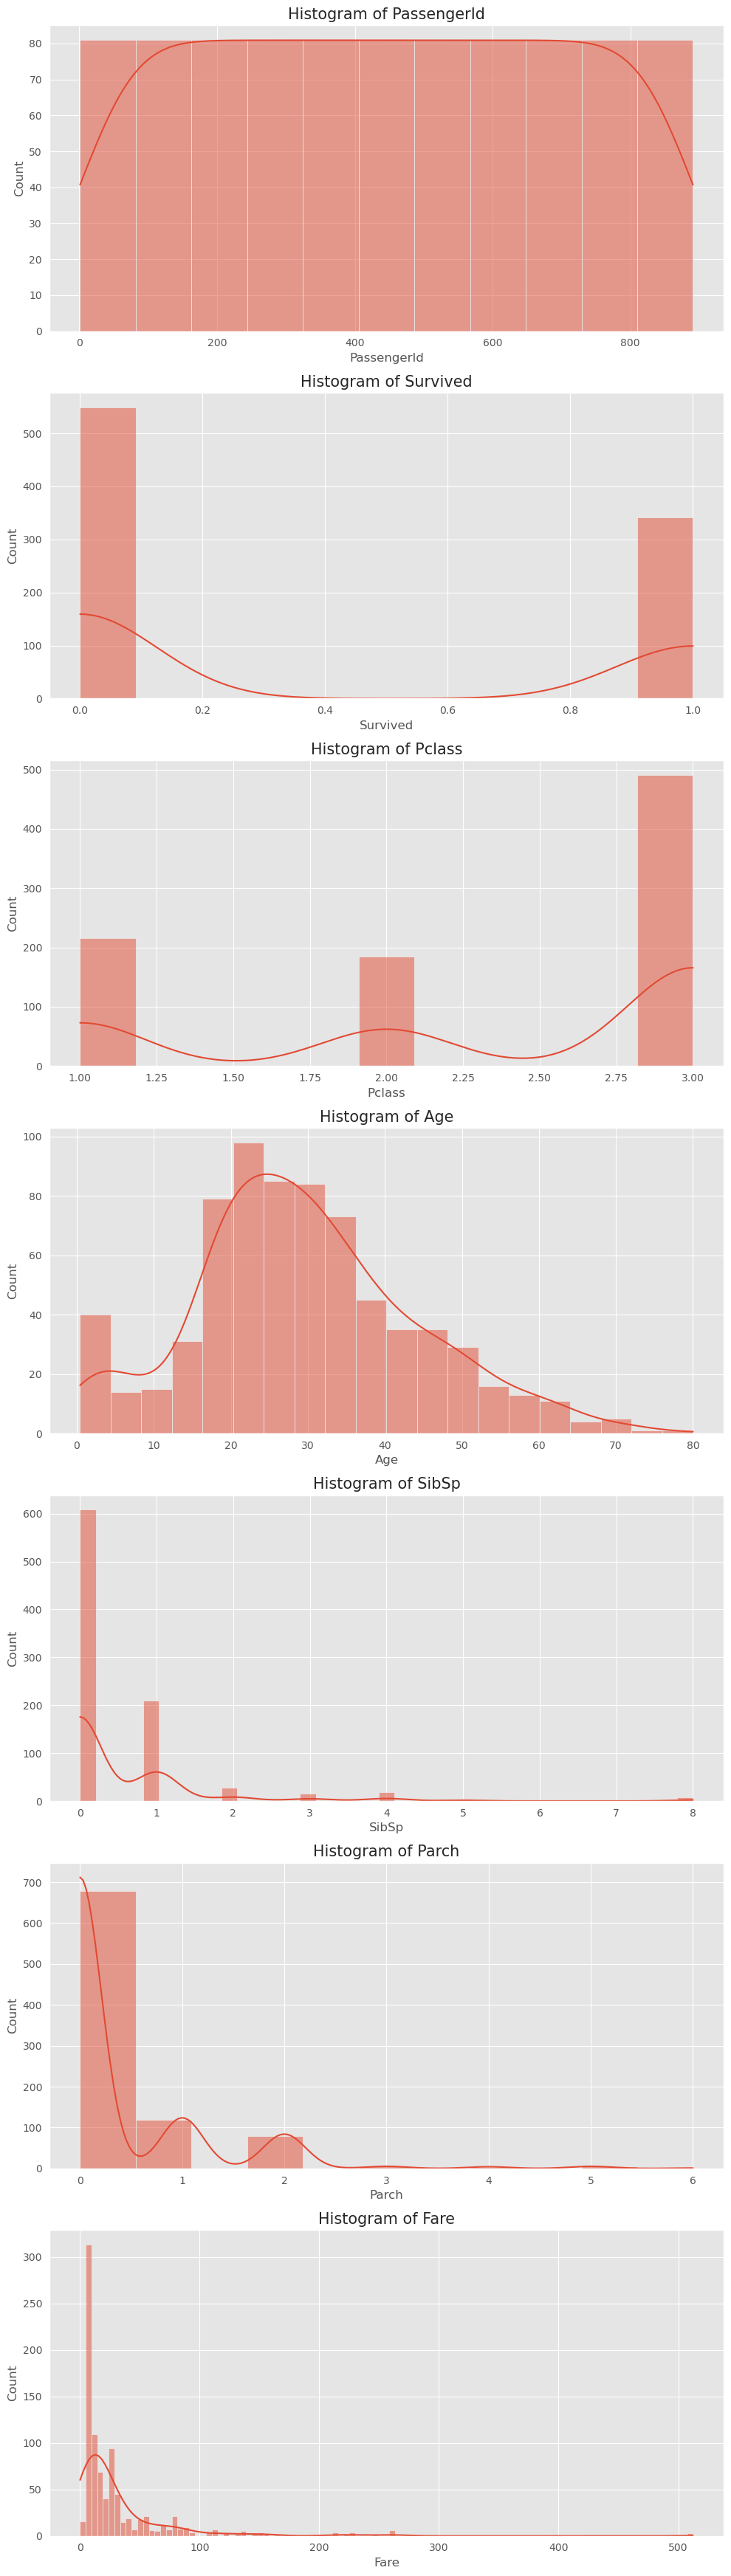

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

def plot_histograms(df, features):
    fig, axs = plt.subplots(len(features), 1, figsize=(10, len(features)*5))
    for i, feature in enumerate(features):
        sns.histplot(data=df, x=feature, kde=True, ax=axs[i])
        axs[i].set_title(f'Histogram of {feature}', fontsize=15)
    plt.tight_layout()
    plt.show()


# List of numerical features in the Titanic dataset
numerical_features = train_df.select_dtypes(exclude='object')

# Call the function
plot_histograms(train_df, numerical_features.columns)


In [120]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [121]:
train_df.shape

(891, 12)

In [122]:
test_df.shape

(418, 11)

## Few statistics on the data

### Missing data

In [123]:
def missing_data(data):
    total = data.isnull().sum()
    percent = (data.isnull().sum()/data.isnull().count()*100)
    tt = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    types = []
    for col in data.columns:
        dtype = str(data[col].dtype)
        types.append(dtype)
    tt['Types'] = types
    return(np.transpose(tt))

In [124]:
missing_data(train_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,0,0,0,0,0,177,0,0,0,0,687,2
Percent,0.0,0.0,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,0.0,77.104377,0.224467
Types,int64,int64,int64,object,object,float64,int64,int64,object,float64,object,object


In [125]:
missing_data(test_df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,0,0,0,0,86,0,0,0,1,327,0
Percent,0.0,0.0,0.0,0.0,20.574163,0.0,0.0,0.0,0.239234,78.229665,0.0
Types,int64,int64,object,object,float64,int64,int64,object,float64,object,object


### Most frequent data

In [126]:
def most_frequent_values(data):
    total = data.count()
    tt = pd.DataFrame(total)
    tt.columns = ['Total']
    items = []
    vals = []
    for col in data.columns:
        try:
            itm = data[col].value_counts().index[0]
            val = data[col].value_counts().values[0]
            items.append(itm)
            vals.append(val)
        except Exception as ex:
            print(ex)
            items.append(0)
            vals.append(0)
            continue
    tt['Most frequent item'] = items
    tt['Frequence'] = vals
    tt['Percent from total'] = np.round(vals / total * 100, 3)
    return(np.transpose(tt))

In [127]:
most_frequent_values(train_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,891,891,891,891,891,714,891,891,891,891,204,889
Most frequent item,1,0,3,"Braund, Mr. Owen Harris",male,24.0,0,0,347082,8.05,B96 B98,S
Frequence,1,549,491,1,577,30,608,678,7,43,4,644
Percent from total,0.112,61.616,55.107,0.112,64.759,4.202,68.238,76.094,0.786,4.826,1.961,72.441


In [128]:
most_frequent_values(test_df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,418,418,418,418,332,418,418,418,417,91,418
Most frequent item,892,3,"Kelly, Mr. James",male,21.0,0,0,PC 17608,7.75,B57 B59 B63 B66,S
Frequence,1,218,1,266,17,283,324,5,21,3,270
Percent from total,0.239,52.153,0.239,63.636,5.12,67.703,77.512,1.196,5.036,3.297,64.593


### Unique values

In [129]:
def unique_values(data):
    total = data.count()
    tt = pd.DataFrame(total)
    tt.columns = ['Total']
    uniques = []
    for col in data.columns:
        unique = data[col].nunique()
        uniques.append(unique)
    tt['Uniques'] = uniques
    return(np.transpose(tt))

In [130]:
unique_values(train_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,891,891,891,891,891,714,891,891,891,891,204,889
Uniques,891,2,3,891,2,88,7,7,681,248,147,3


In [131]:
unique_values(test_df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Total,418,418,418,418,332,418,418,418,417,91,418
Uniques,418,3,418,2,79,7,8,363,169,76,3


# Exploratory data analysis

## Univariate analysis for all features


We show here two graphs in paralel:
* distribution of class values, split per Survived value
* comparison of class values, in train and test data


Let's first aggregate train and test data into one single dataframe, `all_df`.

Notebook Color Schema:


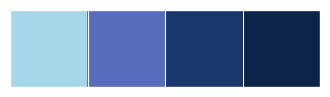

In [132]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
def set_color_map(color_list):
    cmap_custom = ListedColormap(color_list)
    print("Notebook Color Schema:")
    sns.palplot(sns.color_palette(color_list))
    plt.show()
    return cmap_custom
color_list = ["#A5D7E8", "#576CBC", "#19376D", "#0b2447"]
cmap_custom = set_color_map(color_list)

In [133]:
all_df = pd.concat([train_df, test_df], axis=0)
all_df["set"] = "train"
all_df.loc[all_df.Survived.isna(), "set"] = "test"

In [224]:
all_df['Survived']

0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
413    NaN
414    NaN
415    NaN
416    NaN
417    NaN
Name: Survived, Length: 1309, dtype: float64

In [134]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,set
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


### Visual identity of our Notebook

We will use a unified set of colors for the graphs in our Notebook.  

For this Titanic Notebook, let's select a group of **marine** shades of blue.

We use as well a small function to visualize this color map.

In [135]:
def set_color_map(color_list):
    cmap_custom = ListedColormap(color_list)
    print("Notebook Color Schema:")
    sns.palplot(sns.color_palette(color_list))
    plt.show()
    return cmap_custom

Notebook Color Schema:


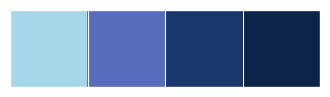

In [136]:
color_list = ["#A5D7E8", "#576CBC", "#19376D", "#0b2447"]
cmap_custom = set_color_map(color_list)

In [225]:
def plot_count_pairs(data_df, feature, title, hue="set"):
    f, ax = plt.subplots(1, 1, figsize=(8, 4))
    sns.countplot(x=feature, data=data_df, hue=hue, palette= color_list)
    plt.grid(color="black", linestyle="-.", linewidth=0.5, axis="y", which="major")
    ax.set_title(f"Number of passengers / {title}")
    plt.show()    

In [138]:
def plot_distribution_pairs(data_df, feature, title, hue="set"):
    f, ax = plt.subplots(1, 1, figsize=(8, 4))
    for i, h in enumerate(data_df[hue].unique()):
        g = sns.histplot(data_df.loc[data_df[hue]==h, feature], color=color_list[i], ax=ax, label=h)
    ax.set_title(f"Number of passengers / {title}")
    g.legend()
    plt.show()

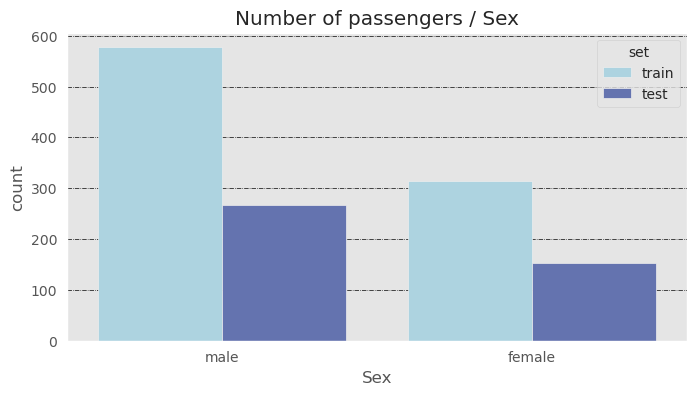

In [139]:
plot_count_pairs(all_df,  "Sex", "Sex")

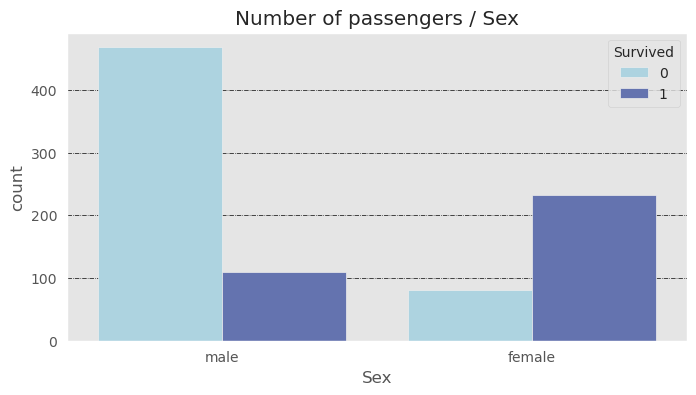

In [140]:
plot_count_pairs(train_df,  "Sex", "Sex", hue="Survived")

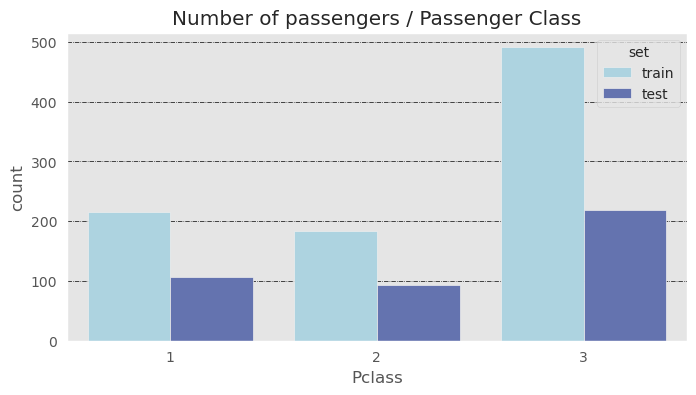

In [141]:
plot_count_pairs(all_df,  "Pclass", "Passenger Class")

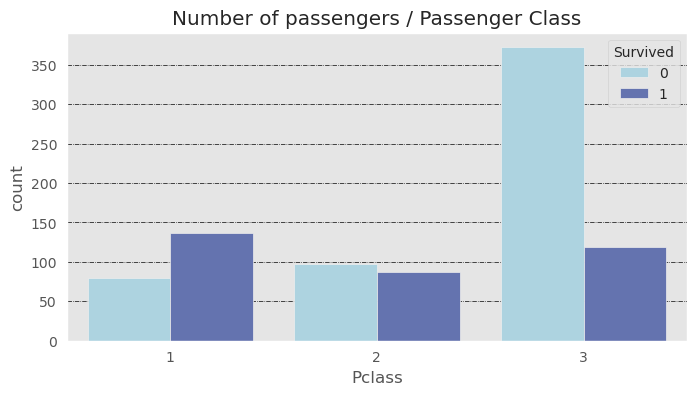

In [142]:
plot_count_pairs(train_df,  "Pclass", "Passenger Class", hue="Survived")

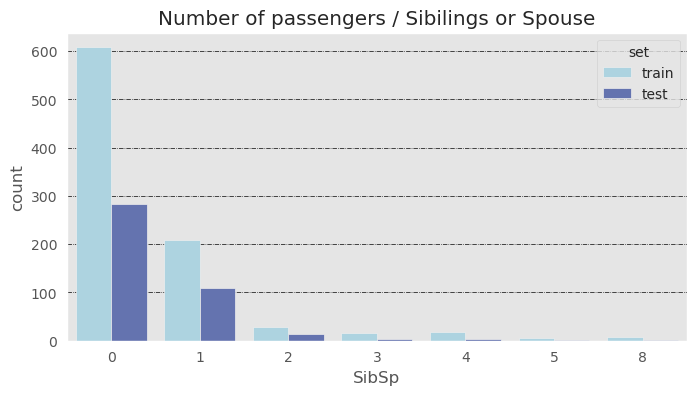

In [143]:
plot_count_pairs(all_df,  "SibSp", "Sibilings or Spouse")

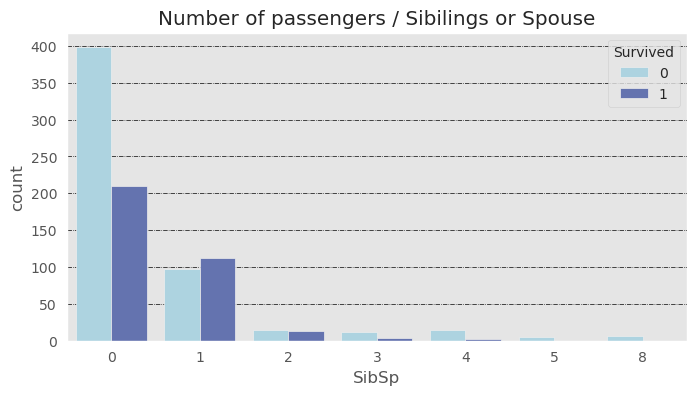

In [144]:
plot_count_pairs(train_df,  "SibSp", "Sibilings or Spouse", hue="Survived")

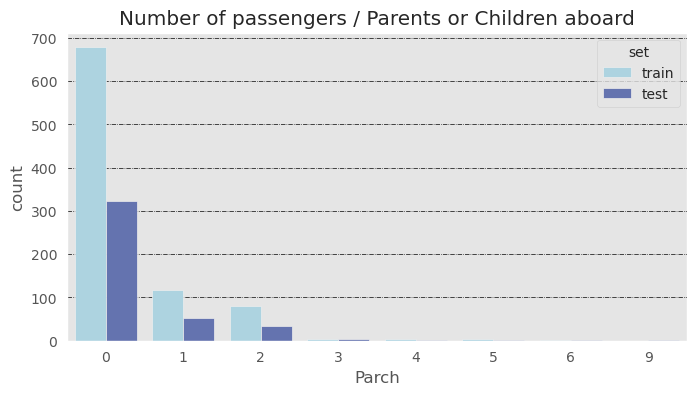

In [145]:
plot_count_pairs(all_df,  "Parch", "Parents or Children aboard")

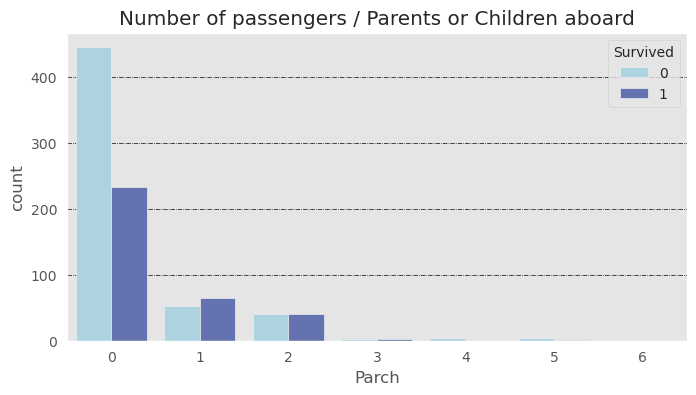

In [146]:
plot_count_pairs(train_df,  "Parch", "Parents or Children aboard", hue="Survived")

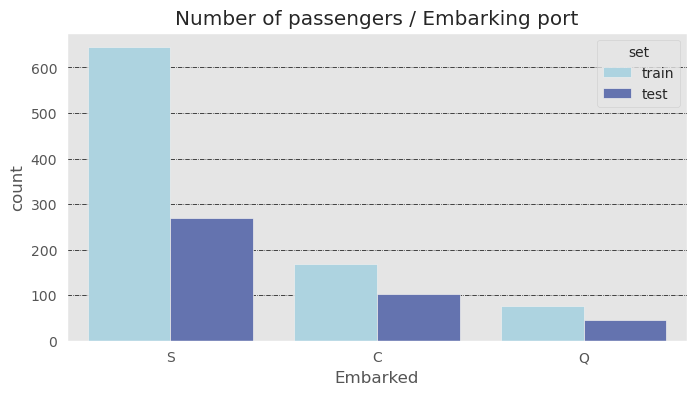

In [147]:
plot_count_pairs(all_df,  "Embarked", "Embarking port")

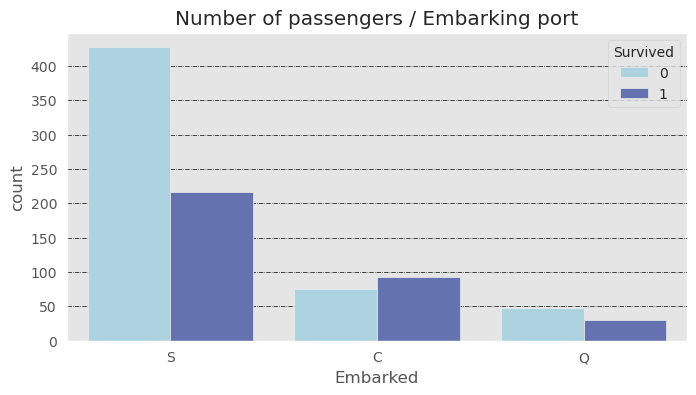

In [148]:
plot_count_pairs(train_df,  "Embarked", "Embarking port", hue="Survived")

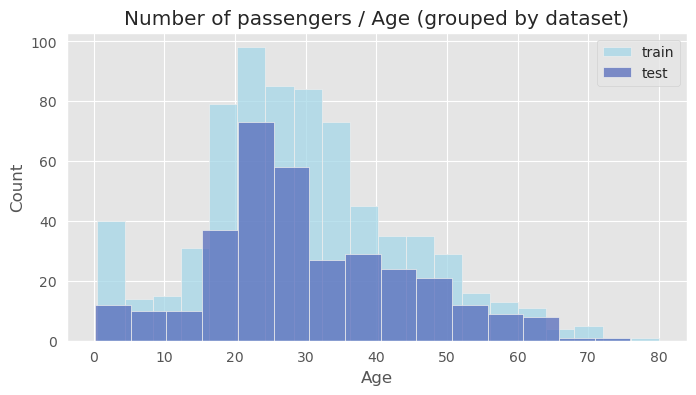

In [149]:
plot_distribution_pairs(all_df, "Age", "Age (grouped by dataset)")

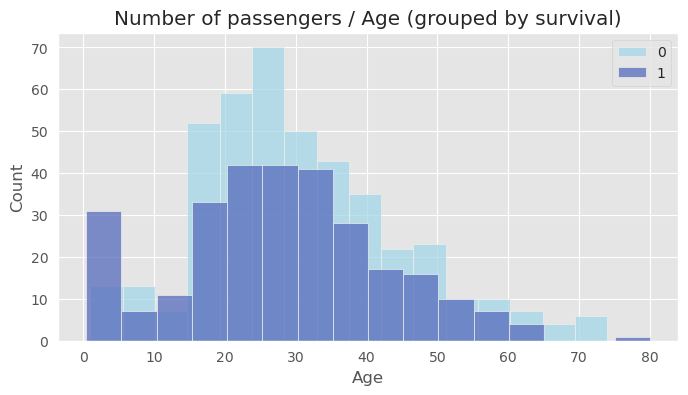

In [150]:
plot_distribution_pairs(train_df, "Age", "Age (grouped by survival)", hue="Survived")

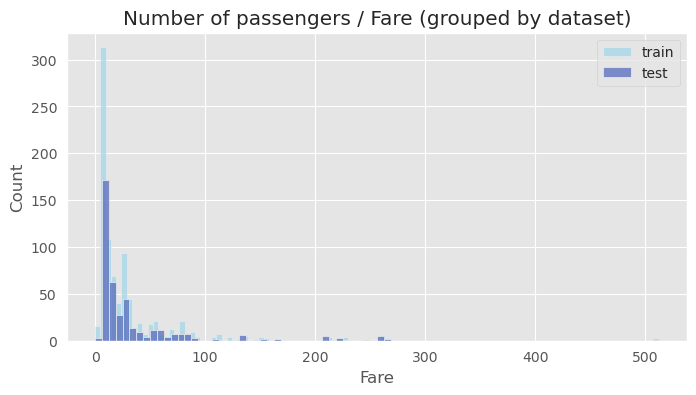

In [151]:
plot_distribution_pairs(all_df, "Fare", "Fare (grouped by dataset)")

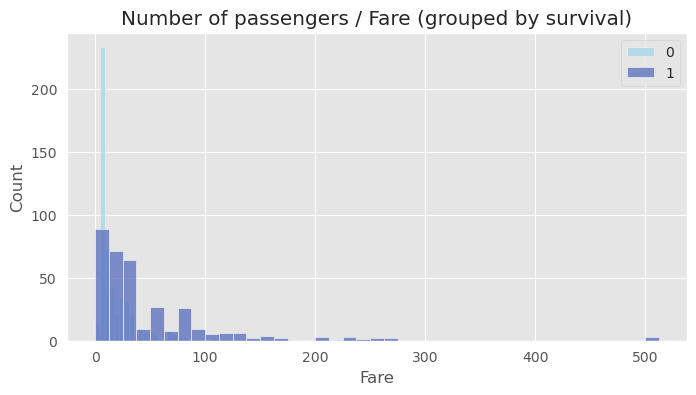

In [152]:
plot_distribution_pairs(train_df, "Fare", "Fare (grouped by survival)", hue="Survived")

## Family size


Based on SibSp (sibilings or spouse) and Parch (parents or children), we set the Family Size field.

In [153]:
all_df["Family Size"] = all_df["SibSp"] + all_df["Parch"] + 1

In [154]:
train_df["Family Size"] = train_df["SibSp"] + train_df["Parch"] + 1

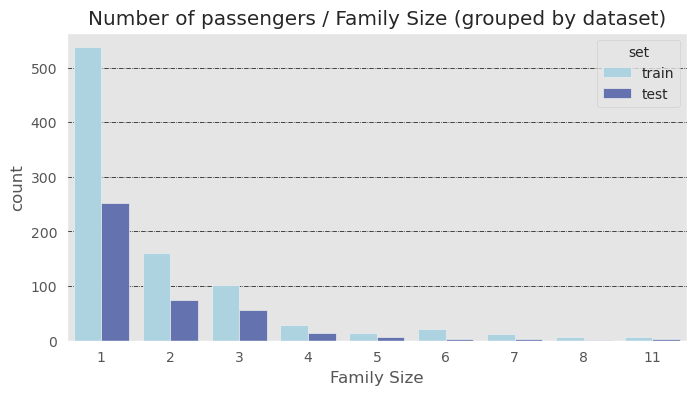

In [155]:
plot_count_pairs(all_df, "Family Size", "Family Size (grouped by dataset)")

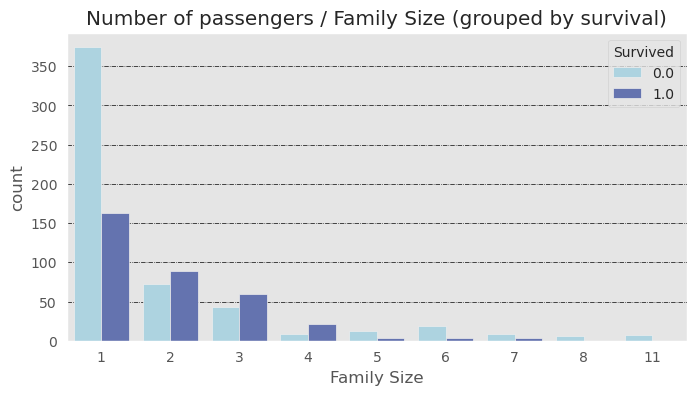

In [156]:
plot_count_pairs(all_df, "Family Size", "Family Size (grouped by survival)", hue="Survived")

## Age interval

In [157]:
all_df["Age Interval"] = 0.0
all_df.loc[ all_df['Age'] <= 16, 'Age Interval']  = 0
all_df.loc[(all_df['Age'] > 16) & (all_df['Age'] <= 32), 'Age Interval'] = 1
all_df.loc[(all_df['Age'] > 32) & (all_df['Age'] <= 48), 'Age Interval'] = 2
all_df.loc[(all_df['Age'] > 48) & (all_df['Age'] <= 64), 'Age Interval'] = 3
all_df.loc[ all_df['Age'] > 64, 'Age Interval'] = 4

In [158]:
train_df["Age Interval"] = 0.0
train_df.loc[train_df['Age'] <= 16, 'Age Interval']  = 0
train_df.loc[(train_df['Age'] > 16) & (train_df['Age'] <= 32), 'Age Interval'] = 1
train_df.loc[(train_df['Age'] > 32) & (train_df['Age'] <= 48), 'Age Interval'] = 2
train_df.loc[(train_df['Age'] > 48) & (train_df['Age'] <= 64), 'Age Interval'] = 3
train_df.loc[ train_df['Age'] > 64, 'Age Interval'] = 4

In [159]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,set,Family Size,Age Interval
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train,2,1.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train,2,2.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train,1,1.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train,2,2.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train,1,2.0


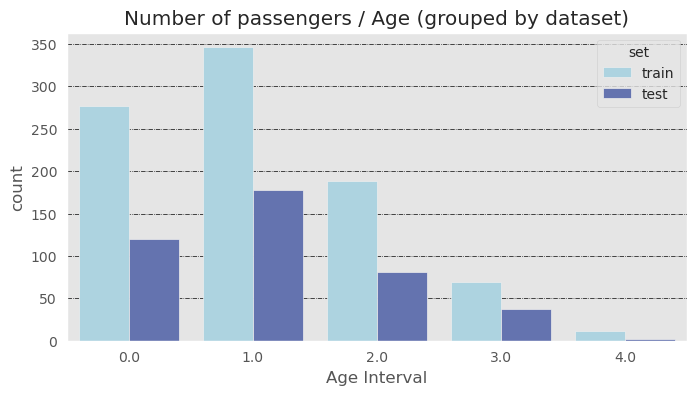

In [160]:
plot_count_pairs(all_df, "Age Interval", "Age (grouped by dataset)")

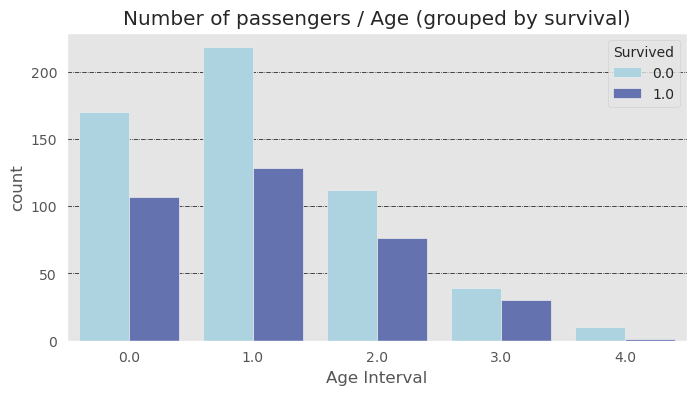

In [161]:
plot_count_pairs(all_df, "Age Interval", "Age (grouped by survival)", hue="Survived")

## Fare interval

In [162]:
all_df['Fare Interval'] = 0.0
all_df.loc[ all_df['Fare'] <= 7.91, 'Fare Interval'] = 0
all_df.loc[(all_df['Fare'] > 7.91) & (all_df['Fare'] <= 14.454), 'Fare Interval'] = 1
all_df.loc[(all_df['Fare'] > 14.454) & (all_df['Fare'] <= 31), 'Fare Interval']   = 2
all_df.loc[ all_df['Fare'] > 31, 'Fare Interval'] = 3

In [163]:
train_df['Fare Interval'] = 0.0
train_df.loc[ train_df['Fare'] <= 7.91, 'Fare Interval'] = 0
train_df.loc[(train_df['Fare'] > 7.91) & (train_df['Fare'] <= 14.454), 'Fare Interval'] = 1
train_df.loc[(train_df['Fare'] > 14.454) & (train_df['Fare'] <= 31), 'Fare Interval']   = 2
train_df.loc[ train_df['Fare'] > 31, 'Fare Interval'] = 3

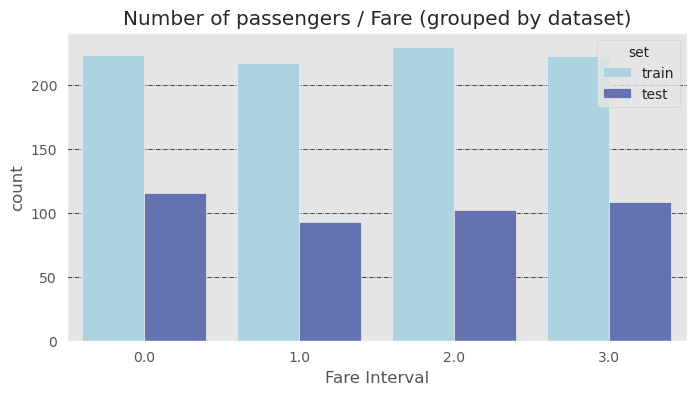

In [164]:
plot_count_pairs(all_df, "Fare Interval", "Fare (grouped by dataset)")

Let's create a composed feature: Pclass + Sex.

In [ ]:
train_df["Sex_Pclass"] = train_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)

In [228]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Family Size,Age Interval,Fare Interval,Sex_Pclass,Family Name,Title,Given Name,Maiden Name,Family Type,Titles
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,2,1.0,0.0,M_C3,Braund,Mr.,Owen Harris,None,Small,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,2,2.0,3.0,F_C1,Cumings,Mrs.,John Bradley,Florence Briggs Thayer,Small,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,1,1.0,1.0,F_C3,Heikkinen,Miss.,Laina,None,Single,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,2,2.0,3.0,F_C1,Futrelle,Mrs.,Jacques Heath,Lily May Peel,Small,Mrs.
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,2.0,1.0,M_C3,Allen,Mr.,William Henry,None,Single,Mr.


In [166]:
all_df["Sex_Pclass"] = all_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)

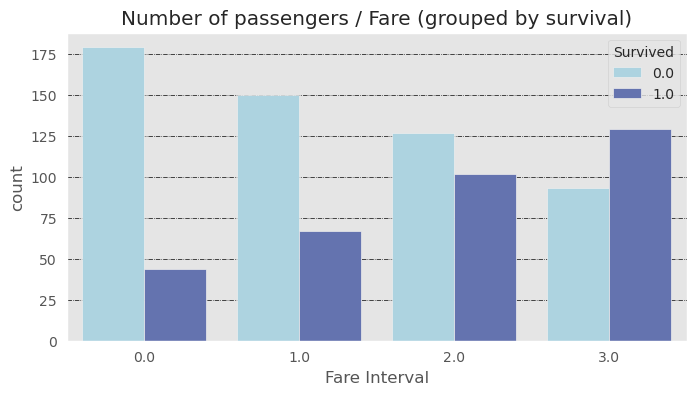

In [167]:
plot_count_pairs(all_df, "Fare Interval", "Fare (grouped by survival)", hue="Survived")

## Deck

Based on Cabin code, we extract the deck name

In [168]:
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"

In [169]:
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

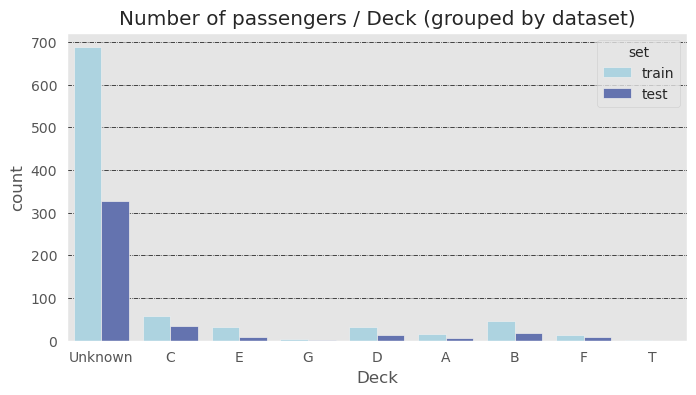

In [170]:
plot_count_pairs(all_df, "Deck", "Deck (grouped by dataset)")

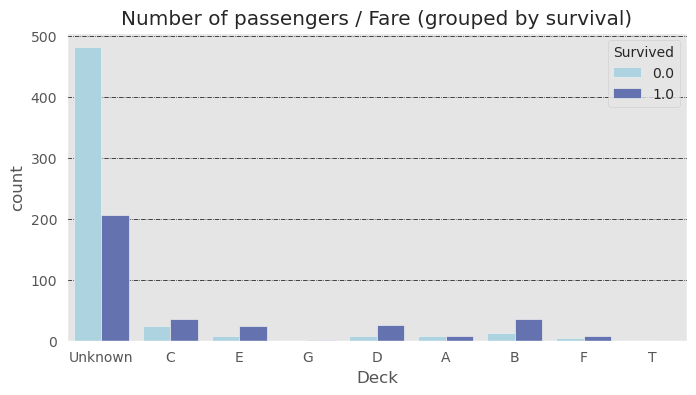

In [171]:
plot_count_pairs(all_df, "Deck", "Fare (grouped by survival)", hue="Survived")

In [172]:
np.transpose(pd.crosstab(all_df['Deck'], all_df['Pclass']))

Deck,A,B,C,D,E,F,G,T,Unknown
Pclass,,,,,,,,,
1,22,65,94,40,34,0,0,1,67
2,0,0,0,6,4,13,0,0,254
3,0,0,0,0,3,8,5,0,693


## Process names


When we process names, we would like to extract the following information:

- Family name - this is the first word (or few first words, if a family name with multiple names), followed by a comma  
- Title - this follows just after the comma   
- Given name - this is the word or group of words following family name  
- Maiden name - for ladies, is given between parantheses  

We start with creating a function that parses the Name string and extract (if possible) these 4 elements


In [173]:
def parse_names(row):
    try:
        text = row["Name"]
        split_text = text.split(",")
        family_name = split_text[0]
        next_text = split_text[1]
        split_text = next_text.split(".")
        title = (split_text[0] + ".").lstrip().rstrip()
        next_text = split_text[1]
        if "(" in next_text:
            split_text = next_text.split("(")
            given_name = split_text[0]
            maiden_name = split_text[1].rstrip(")")
            return pd.Series([family_name, title, given_name, maiden_name])
        else:
            given_name = next_text
            return pd.Series([family_name, title, given_name, None])
    except Exception as ex:
        print(f"Exception: {ex}")
    
    

In [174]:
all_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = all_df.apply(lambda row: parse_names(row), axis=1)

In [175]:
train_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = train_df.apply(lambda row: parse_names(row), axis=1)

## Deep dive into titles


Let's check few things about title:  
- relationship between Age Interval and Title;   
- relationship between Sex and Title;  
- relationship between SibSp, Parch, Family Size and Title;  


In [176]:
np.transpose(pd.crosstab(all_df['Title'], all_df['Age Interval']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
Age Interval,,,,,,,,,,,,,,,,,,
0.0,0,0,0,0,1,0,0,0,61,111,0,0,193,30,1,0,0,0
1.0,0,0,0,0,2,0,0,0,0,113,2,1,334,68,1,3,0,0
2.0,0,1,1,1,1,1,1,1,0,29,0,0,163,67,0,2,0,1
3.0,0,3,0,0,4,0,0,1,0,7,0,0,56,31,0,3,1,0
4.0,1,0,0,0,0,0,0,0,0,0,0,0,11,1,0,0,0,0


In [177]:
np.transpose(pd.crosstab(all_df['Title'], all_df['Sex']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
Sex,,,,,,,,,,,,,,,,,,
female,0,0,0,1,1,0,1,0,0,260,2,1,0,197,2,0,0,1
male,1,4,1,0,7,1,0,2,61,0,0,0,757,0,0,8,1,0


In [178]:
np.transpose(pd.crosstab(all_df['Title'], all_df['SibSp']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
SibSp,,,,,,,,,,,,,,,,,,
0,0,3,1,1,5,1,0,2,13,178,2,1,599,76,2,6,0,1
1,1,1,0,0,1,0,1,0,23,45,0,0,130,114,0,2,1,0
2,0,0,0,0,2,0,0,0,2,14,0,0,19,5,0,0,0,0
3,0,0,0,0,0,0,0,0,5,10,0,0,3,2,0,0,0,0
4,0,0,0,0,0,0,0,0,13,7,0,0,2,0,0,0,0,0
5,0,0,0,0,0,0,0,0,3,2,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,0,2,4,0,0,3,0,0,0,0,0


In [179]:
np.transpose(pd.crosstab(all_df['Title'], all_df['Parch']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
Parch,,,,,,,,,,,,,,,,,,
0,0,4,1,1,7,1,1,2,2,174,2,1,686,110,2,6,1,1
1,1,0,0,0,1,0,0,0,34,41,0,0,44,47,0,2,0,0
2,0,0,0,0,0,0,0,0,25,45,0,0,19,24,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,2,6,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,2,4,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,2,4,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0


In [180]:
np.transpose(pd.crosstab(all_df['Title'], all_df['Family Size']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
Family Size,,,,,,,,,,,,,,,,,,
1,0,3,1,1,5,1,0,2,1,150,2,1,579,36,2,5,0,1
2,0,1,0,0,0,0,1,0,5,35,0,0,103,87,0,2,1,0
3,1,0,0,0,3,0,0,0,26,32,0,0,49,47,0,1,0,0
4,0,0,0,0,0,0,0,0,5,16,0,0,9,13,0,0,0,0
5,0,0,0,0,0,0,0,0,4,9,0,0,4,5,0,0,0,0
6,0,0,0,0,0,0,0,0,10,5,0,0,5,5,0,0,0,0
7,0,0,0,0,0,0,0,0,5,7,0,0,2,2,0,0,0,0
8,0,0,0,0,0,0,0,0,3,2,0,0,2,1,0,0,0,0
11,0,0,0,0,0,0,0,0,2,4,0,0,4,1,0,0,0,0


In [181]:
np.transpose(pd.crosstab(all_df['Title'], all_df['Pclass']))

Title,Capt.,Col.,Don.,Dona.,Dr.,Jonkheer.,Lady.,Major.,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the Countess.
Pclass,,,,,,,,,,,,,,,,,,
1,1,4,1,1,6,1,1,2,5,60,2,1,159,77,0,0,1,1
2,0,0,0,0,2,0,0,0,11,50,0,0,150,55,1,8,0,0
3,0,0,0,0,0,0,0,0,45,150,0,0,448,65,1,0,0,0


## Deep dive into families data

We would like to understand what happened with different families, we will follow their fate through the data.

Let's look first to few large families.

In [182]:
sel_columns = ["Name", "Sex","Age", "Title", "Family Name", "Given Name", "Maiden Name", "SibSp", "Parch", "Family Size", "Ticket", "Cabin", "Pclass", "Survived"]

In [183]:
all_df["Family Name"].value_counts()[0:5]

Andersson    11
Sage         11
Goodwin       8
Asplund       8
Davies        7
Name: Family Name, dtype: int64

In [184]:
all_df.loc[all_df["Family Name"]=="Andersson"][sel_columns].sort_values(by=["Family Size", "Ticket", "Age"], ascending=False)

,Name,Sex,Age,Title,Family Name,Given Name,Maiden Name,SibSp,Parch,Family Size,Ticket,Cabin,Pclass,Survived
214,"Andersson, Miss. Ida Augusta Margareta",female,38.0,Miss.,Andersson,Ida Augusta Margareta,None,4,2,7,347091,NaN,3,NaN
13,"Andersson, Mr. Anders Johan",male,39.0,Mr.,Andersson,Anders Johan,None,1,5,7,347082,NaN,3,0.0
610,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,Mrs.,Andersson,Anders Johan,Alfrida Konstantia Brogren,1,5,7,347082,NaN,3,0.0
542,"Andersson, Miss. Sigrid Elisabeth",female,11.0,Miss.,Andersson,Sigrid Elisabeth,None,4,2,7,347082,NaN,3,0.0
541,"Andersson, Miss. Ingeborg Constanzia",female,9.0,Miss.,Andersson,Ingeborg Constanzia,None,4,2,7,347082,NaN,3,0.0
813,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,Miss.,Andersson,Ebba Iris Alfrida,None,4,2,7,347082,NaN,3,0.0
850,"Andersson, Master. Sigvard Harald Elias",male,4.0,Master.,Andersson,Sigvard Harald Elias,None,4,2,7,347082,NaN,3,0.0
119,"Andersson, Miss. Ellis Anna Maria",female,2.0,Miss.,Andersson,Ellis Anna Maria,None,4,2,7,347082,NaN,3,0.0
68,"Andersson, Miss. Erna Alexandra",female,17.0,Miss.,Andersson,Erna Alexandra,None,4,2,7,3101281,NaN,3,1.0
146,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,Mr.,Andersson,August Edvard,"""Wennerstrom""",0,0,1,350043,NaN,3,1.0


In [185]:
all_df.loc[all_df["Family Name"]=="Sage"][sel_columns].sort_values(by=["Family Size", "Ticket", "Age"], ascending=False)

,Name,Sex,Age,Title,Family Name,Given Name,Maiden Name,SibSp,Parch,Family Size,Ticket,Cabin,Pclass,Survived
360,"Sage, Master. William Henry",male,14.5,Master.,Sage,William Henry,None,8,2,11,CA. 2343,NaN,3,NaN
159,"Sage, Master. Thomas Henry",male,NaN,Master.,Sage,Thomas Henry,None,8,2,11,CA. 2343,NaN,3,0.0
180,"Sage, Miss. Constance Gladys",female,NaN,Miss.,Sage,Constance Gladys,None,8,2,11,CA. 2343,NaN,3,0.0
201,"Sage, Mr. Frederick",male,NaN,Mr.,Sage,Frederick,None,8,2,11,CA. 2343,NaN,3,0.0
324,"Sage, Mr. George John Jr",male,NaN,Mr.,Sage,George John Jr,None,8,2,11,CA. 2343,NaN,3,0.0
792,"Sage, Miss. Stella Anna",female,NaN,Miss.,Sage,Stella Anna,None,8,2,11,CA. 2343,NaN,3,0.0
846,"Sage, Mr. Douglas Bullen",male,NaN,Mr.,Sage,Douglas Bullen,None,8,2,11,CA. 2343,NaN,3,0.0
863,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,Miss.,Sage,"Dorothy Edith ""Dolly""",None,8,2,11,CA. 2343,NaN,3,0.0
188,"Sage, Miss. Ada",female,NaN,Miss.,Sage,Ada,None,8,2,11,CA. 2343,NaN,3,NaN
342,"Sage, Mr. John George",male,NaN,Mr.,Sage,John George,None,1,9,11,CA. 2343,NaN,3,NaN


In [186]:
all_df.loc[all_df["Family Name"]=="Asplund"][sel_columns].sort_values(by=["Family Size", "Ticket", "Age"], ascending=False)

,Name,Sex,Age,Title,Family Name,Given Name,Maiden Name,SibSp,Parch,Family Size,Ticket,Cabin,Pclass,Survived
174,"Asplund, Mr. Carl Oscar Vilhelm Gustafsson",male,40.0,Mr.,Asplund,Carl Oscar Vilhelm Gustafsson,None,1,5,7,347077,NaN,3,NaN
25,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,Mrs.,Asplund,Carl Oscar,Selma Augusta Emilia Johansson,1,5,7,347077,NaN,3,1.0
154,"Asplund, Master. Filip Oscar",male,13.0,Master.,Asplund,Filip Oscar,None,4,2,7,347077,NaN,3,NaN
182,"Asplund, Master. Clarence Gustaf Hugo",male,9.0,Master.,Asplund,Clarence Gustaf Hugo,None,4,2,7,347077,NaN,3,0.0
233,"Asplund, Miss. Lillian Gertrud",female,5.0,Miss.,Asplund,Lillian Gertrud,None,4,2,7,347077,NaN,3,1.0
379,"Asplund, Master. Carl Edgar",male,5.0,Master.,Asplund,Carl Edgar,None,4,2,7,347077,NaN,3,NaN
261,"Asplund, Master. Edvin Rojj Felix",male,3.0,Master.,Asplund,Edvin Rojj Felix,None,4,2,7,347077,NaN,3,1.0
226,"Asplund, Mr. Johan Charles",male,23.0,Mr.,Asplund,Johan Charles,None,0,0,1,350054,NaN,3,NaN


Let's understand more about the special case of the women with a Dr. Title. This is rather rare for that period.

In [187]:
all_df.loc[(all_df['Title'] == 'Dr.') & (all_df['Sex'] == 'female')][sel_columns]

,Name,Sex,Age,Title,Family Name,Given Name,Maiden Name,SibSp,Parch,Family Size,Ticket,Cabin,Pclass,Survived
796,"Leader, Dr. Alice (Farnham)",female,49.0,Dr.,Leader,Alice,Farnham,0,0,1,17465,D17,1,1.0


Let's see if she is traveling alone in cabin D17.

In [188]:
all_df.loc[all_df['Cabin'] == 'D17'][sel_columns]

,Name,Sex,Age,Title,Family Name,Given Name,Maiden Name,SibSp,Parch,Family Size,Ticket,Cabin,Pclass,Survived
796,"Leader, Dr. Alice (Farnham)",female,49.0,Dr.,Leader,Alice,Farnham,0,0,1,17465,D17,1,1.0
862,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,Mrs.,Swift,Frederick Joel,Margaret Welles Barron,0,0,1,17466,D17,1,1.0


She is actually traveling with a Mrs. Swift, a woman companion, in the same 1st class cabin, on a separate ticket. They both survived.

### Family Names wordclouds

In [189]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white",
                         colormap=cmap_custom).generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()    

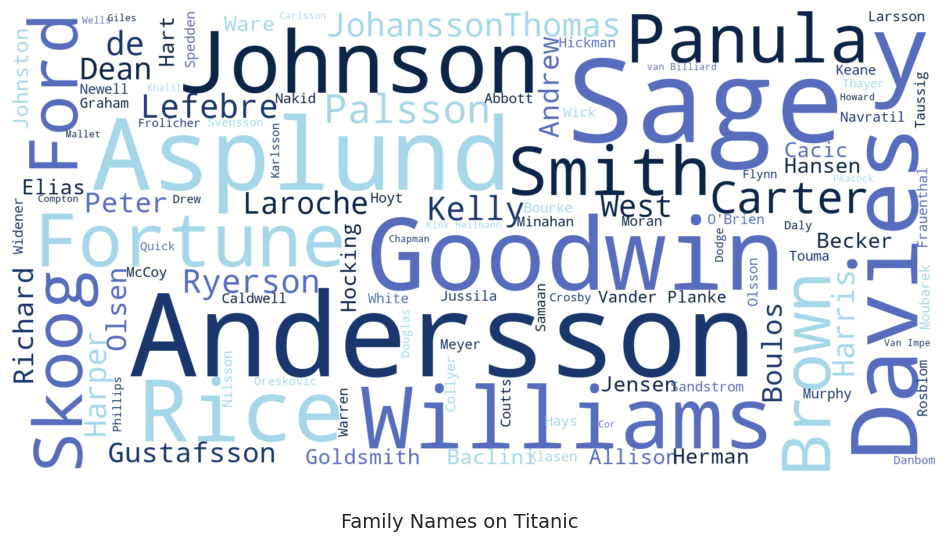

In [190]:
show_wordcloud(all_df["Family Name"], title="Family Names on Titanic")

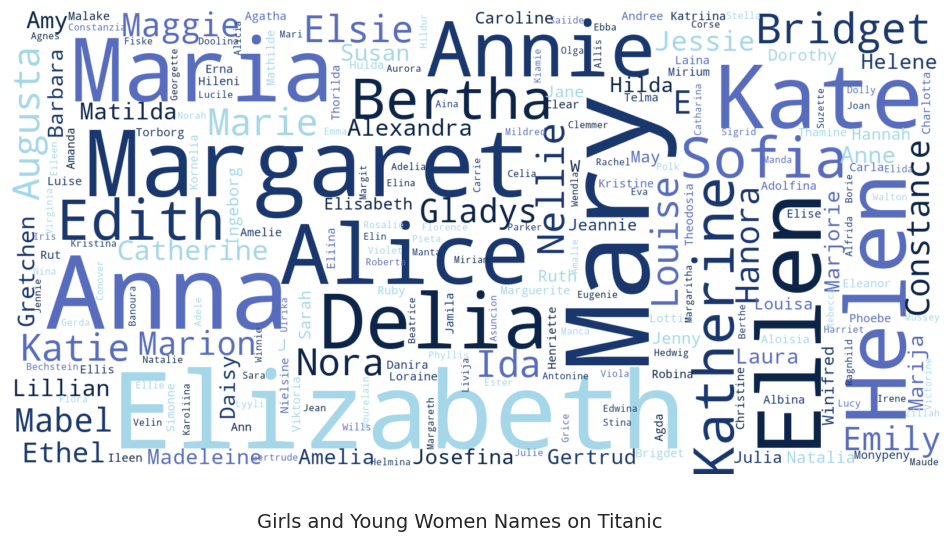

In [191]:
show_wordcloud(all_df.loc[all_df["Title"].isin(["Miss.", "Mlle."])]["Given Name"], title="Girls and Young Women Names on Titanic")

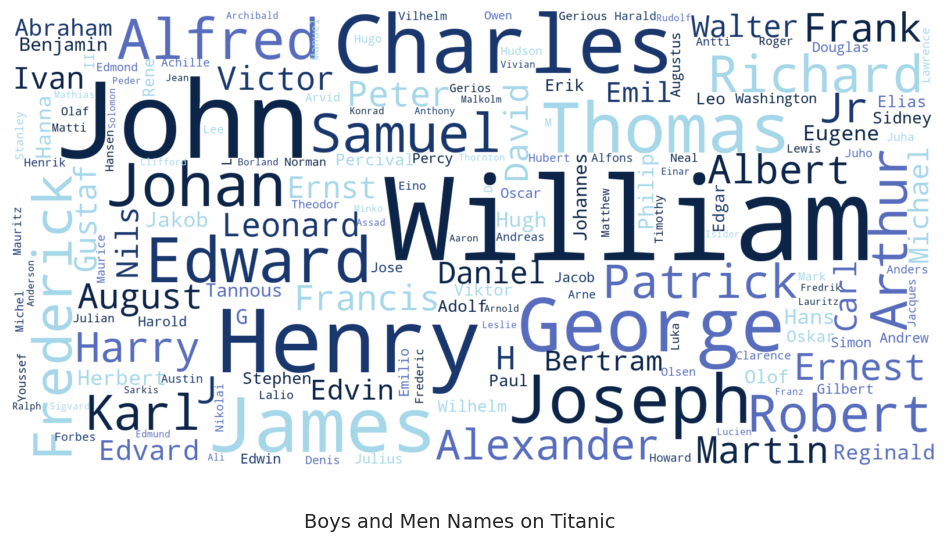

In [192]:
show_wordcloud(all_df.loc[all_df["Sex"]=="male"]["Given Name"], title="Boys and Men Names on Titanic")

In [193]:
all_df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

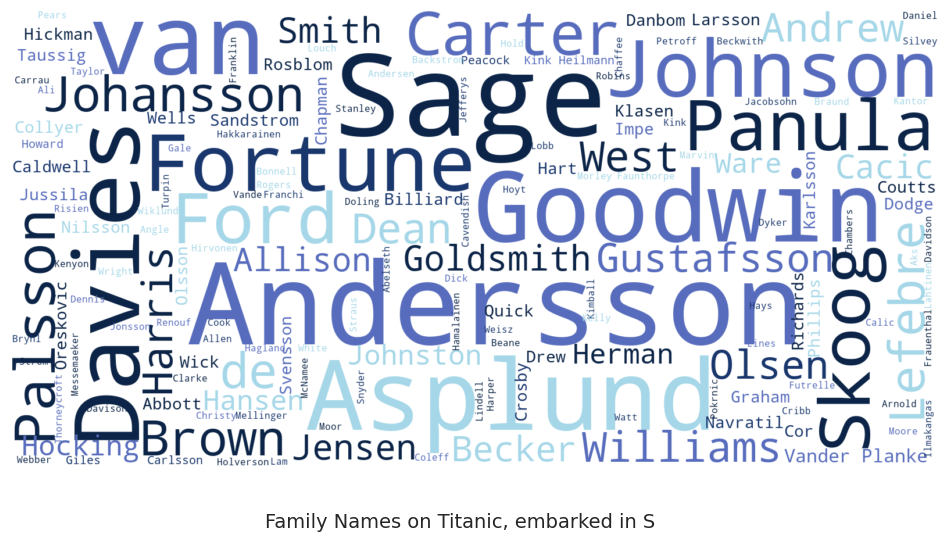

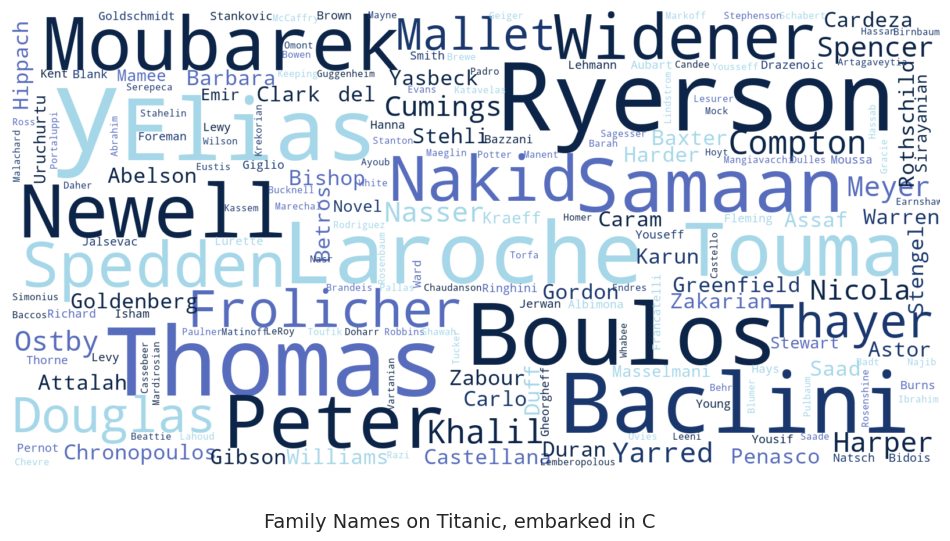

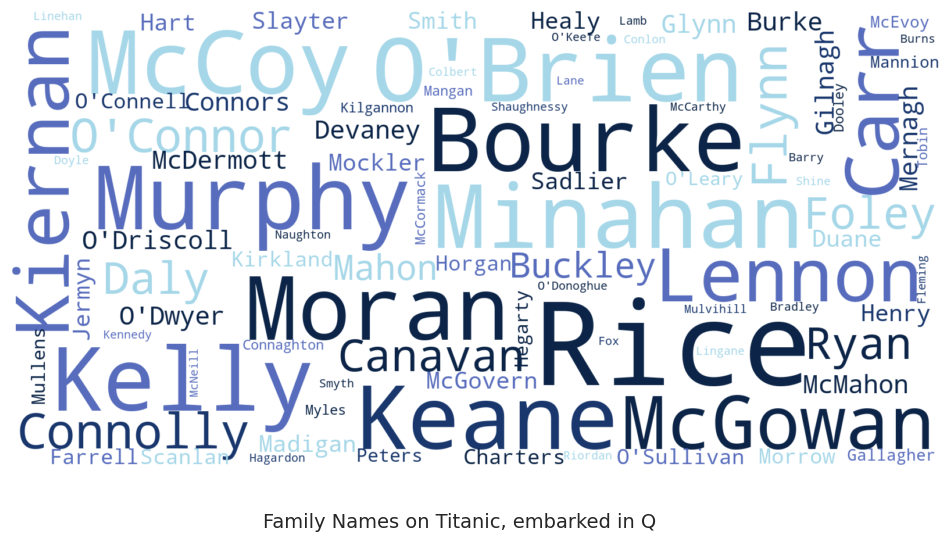

In [194]:
for embark in all_df["Embarked"].unique():
    try:
        show_wordcloud(all_df.loc[all_df["Embarked"]==embark]["Family Name"], title=f"Family Names on Titanic, embarked in {embark}")
    except:
        pass

## Multivariate analysis


Let's look now to the interaction of multiple features.

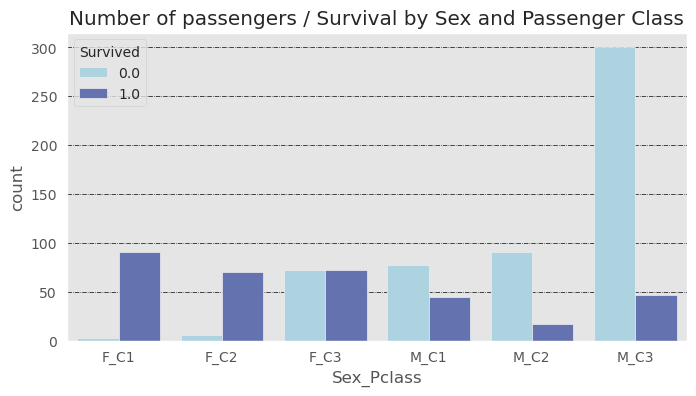

In [195]:
plot_count_pairs(all_df.sort_values(by=("Sex_Pclass")), "Sex_Pclass", "Survival by Sex and Passenger Class", "Survived")

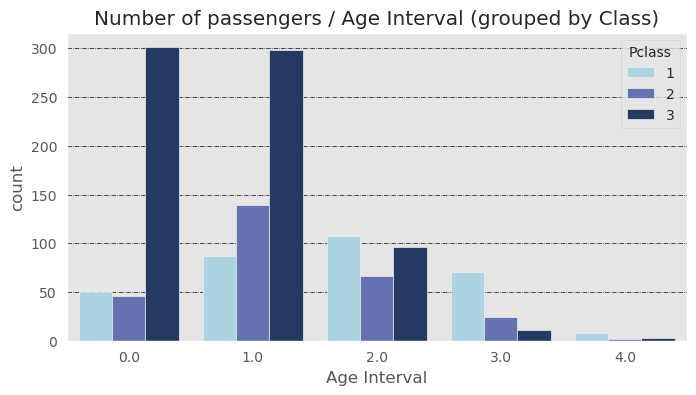

In [196]:
plot_count_pairs(all_df, "Age Interval", "Age Interval (grouped by Class)", "Pclass")

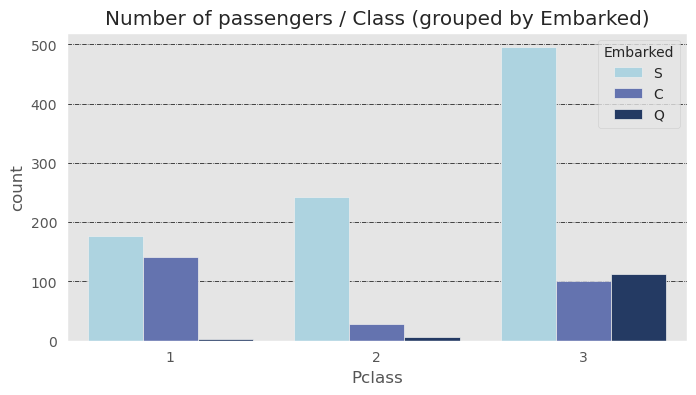

In [197]:
plot_count_pairs(all_df, "Pclass", "Class (grouped by Embarked)", "Embarked")

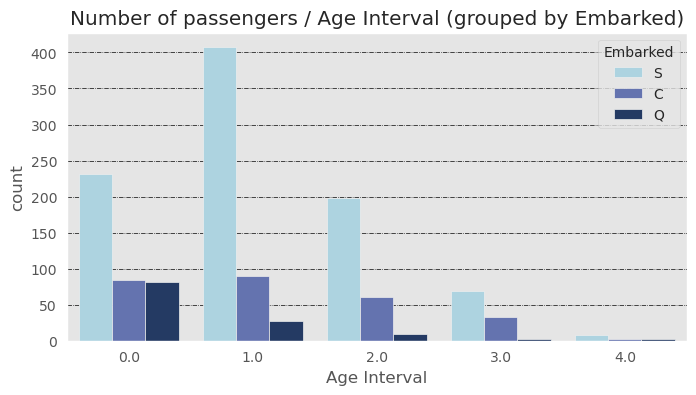

In [198]:
plot_count_pairs(all_df, "Age Interval", "Age Interval (grouped by Embarked)", "Embarked")

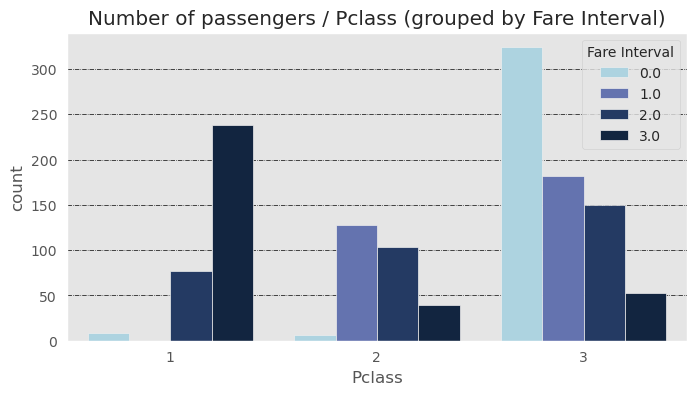

In [199]:
plot_count_pairs(all_df, "Pclass", "Pclass (grouped by Fare Interval)", "Fare Interval")

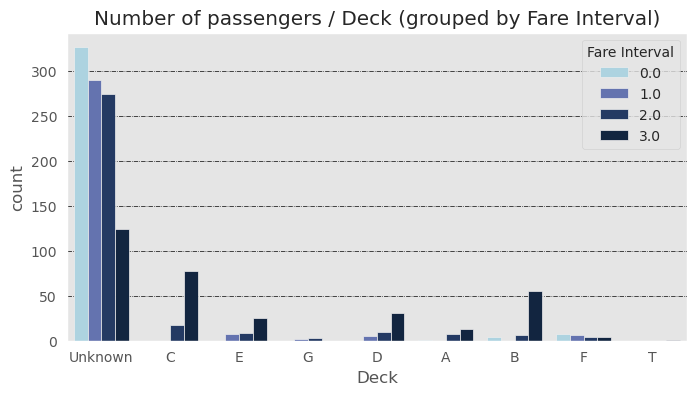

In [200]:
plot_count_pairs(all_df, "Deck", "Deck (grouped by Fare Interval)", "Fare Interval")

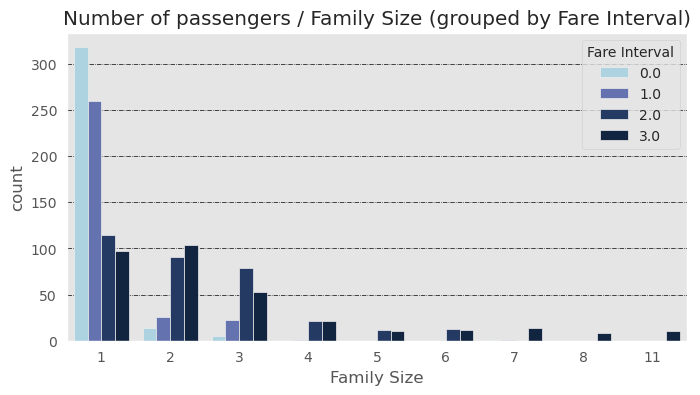

In [201]:
plot_count_pairs(all_df, "Family Size", "Family Size (grouped by Fare Interval)", "Fare Interval")

In [202]:
def plot_count_distrib_pairs(data_df, f_one, f_two, title, hue="Survived"):
    sns.set_style("whitegrid", {'axes.grid' : True})
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    sns.kdeplot(x=data_df[f_one], y=data_df[f_two], hue=data_df[hue], palette=color_list)
    ax.set_zlabel('Density')
    ax.set_title(title)
    plt.show()    

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  """


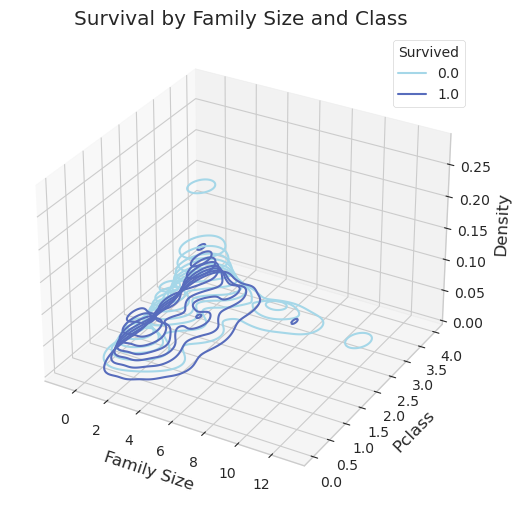

In [203]:
plot_count_distrib_pairs(all_df, "Family Size", "Pclass", "Survival by Family Size and Class")

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  """


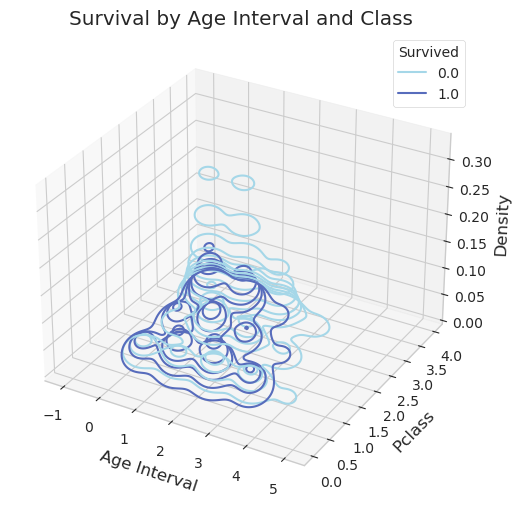

In [204]:
plot_count_distrib_pairs(all_df, "Age Interval", "Pclass", "Survival by Age Interval and Class")

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  """Entry point for launching an IPython kernel.


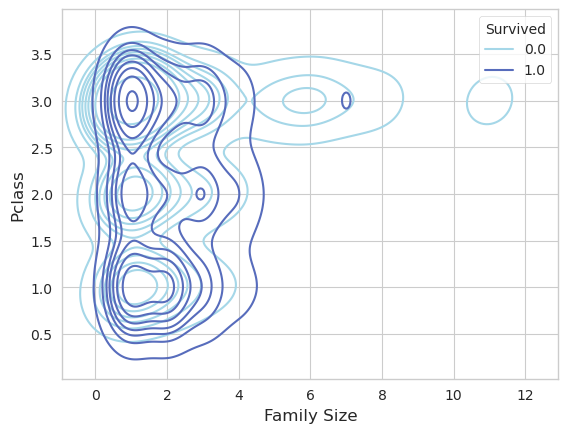

In [205]:
sns.kdeplot(x=all_df["Family Size"], y=all_df["Pclass"], hue=all_df["Survived"], palette= color_list[0:3])
plt.show()

### Few more engineered data 


Let's create two more engineered features:  
* Family size interval: Single, Small, Large  
* Aggregated titles: Mr, Mrs, Master, Miss, and Rare  

In [206]:
for dataset in [all_df, train_df]:
    dataset["Family Type"] = dataset["Family Size"]

In [207]:
for dataset in [all_df, train_df]:
    dataset.loc[dataset["Family Size"] == 1, "Family Type"] = "Single"
    dataset.loc[(dataset["Family Size"] > 1) & (dataset["Family Size"] < 5), "Family Type"] = "Small"
    dataset.loc[(dataset["Family Size"] >= 5), "Family Type"] = "Large"

In [208]:
for dataset in [all_df, train_df]:
    dataset["Titles"] = dataset["Title"]

In [209]:

for dataset in [all_df, train_df]:
    #unify `Miss`
    dataset['Titles'] = dataset['Titles'].replace('Mlle.', 'Miss.')
    dataset['Titles'] = dataset['Titles'].replace('Ms.', 'Miss.')
    #unify `Mrs`
    dataset['Titles'] = dataset['Titles'].replace('Mme.', 'Mrs.')
    # unify Rare
    dataset['Titles'] = dataset['Titles'].replace(['Lady.', 'the Countess.','Capt.', 'Col.',\
     'Don.', 'Dr.', 'Major.', 'Rev.', 'Sir.', 'Jonkheer.', 'Dona.'], 'Rare')

In [210]:
train_df[['Titles', 'Sex', 'Survived']].groupby(['Titles', 'Sex'], as_index=False).mean()

,Titles,Sex,Survived
0,Master.,male,0.575000
1,Miss.,female,0.702703
2,Mr.,male,0.156673
3,Mrs.,female,0.793651
4,Rare,female,1.000000
5,Rare,male,0.250000


## Complex analysis in one graph

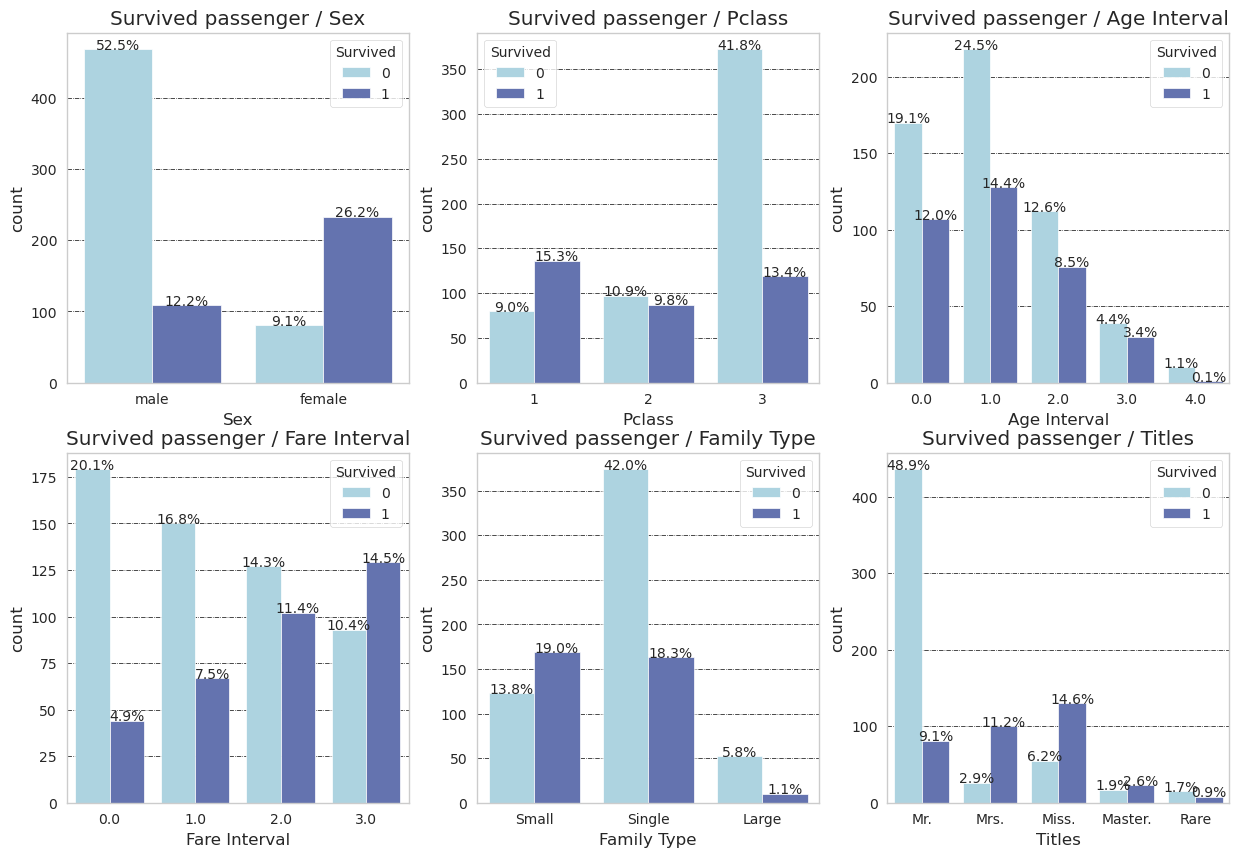

In [211]:
f, ax = plt.subplots(2, 3, figsize=(15, 10))

features = ["Sex", "Pclass", "Age Interval", "Fare Interval", "Family Type", "Titles"]

for i, feature in enumerate(features):
    crt_ax = (int(i/3), i%3)
    total = float(len(train_df))
    sns.countplot(x=feature, data=train_df, hue="Survived", palette= color_list, ax = ax[crt_ax])
    ax[crt_ax].grid(color="black", linestyle="-.", linewidth=0.5, axis="y", which="major")
    ax[crt_ax].set_title(f"Survived passenger / {feature}")
    for p in ax[crt_ax].patches:
        height = p.get_height()
        ax[crt_ax].text(p.get_x()+p.get_width()/2.,
                height,
                '{:1.1f}%'.format(100*height/total),
                ha="center", fontsize=10) 


plt.show()    



# Baseline model

In [212]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

## Map categorical value to numerical values

In [213]:
for dataset in [train_df, test_df]:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

Create train-validation split.

In [214]:
VALID_SIZE = 0.2
train, valid = train_test_split(train_df, test_size=VALID_SIZE, random_state=42, shuffle=True)

Define predictor features and target feature.

In [215]:
predictors = ["Sex", "Pclass"]
target = 'Survived'

Define the training and validation data and labels.

In [216]:
train_X = train[predictors]
train_Y = train[target].values
valid_X = valid[predictors]
valid_Y = valid[target].values

Initialize the classifiction algorithm.

In [217]:
clf = RandomForestClassifier(n_jobs=-1, 
                             random_state=42,
                             criterion="gini",
                             n_estimators=100,
                             verbose=False)

Fit the classifier with the training data.

In [218]:
clf.fit(train_X, train_Y)

RandomForestClassifier(n_jobs=-1, random_state=42, verbose=False)

Predict the train data (to check the training classification error).

In [219]:
preds_tr = clf.predict(train_X)

Predict the validation data.

In [220]:
preds = clf.predict(valid_X)

Classification report for training data.

In [221]:
print(metrics.classification_report(train_Y, preds_tr, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.75      0.99      0.86       444
    Survived       0.96      0.47      0.63       268

    accuracy                           0.79       712
   macro avg       0.86      0.73      0.74       712
weighted avg       0.83      0.79      0.77       712



Classification report for validation data.

In [222]:
print(metrics.classification_report(valid_Y, preds, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.73      0.96      0.83       105
    Survived       0.90      0.49      0.63        74

    accuracy                           0.77       179
   macro avg       0.81      0.72      0.73       179
weighted avg       0.80      0.77      0.75       179

